<a href="https://colab.research.google.com/github/Savcdilara/MicrosoftStaj/blob/main/RSAkeyGeneration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ====================================================
# 🔐 RSA Key Generation and Entropy Evaluation
# ====================================================
# Author: Dilara Savcı
# Project: AI-Based Dynamic Key Generation System
# Dataset: CIC-IDS2017
# Method: AES Key Generation (Baseline)
# ====================================================
!pip install pycryptodome
import pandas as pd
import numpy as np
import secrets
import time
import matplotlib.pyplot as plt
from google.colab import drive
import glob
from Crypto.PublicKey import RSA
from Crypto.Random import get_random_bytes



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 24.8 MB/s eta 0:00:00


In [ ]:
# ====================================================
# 1️⃣ Load Dataset
# ====================================================
drive.mount('/content/drive')

path = "/content/drive/MyDrive/MachineLearningCVE/"
files = glob.glob(path + "*.csv")

df_list = []
for file in files:
    temp = pd.read_csv(file, low_memory=False)
    df_list.append(temp)

df = pd.concat(df_list, axis=0, ignore_index=True)
print("✅ Dataset loaded successfully")
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Mounted at /content/drive
✅ Dataset loaded successfully
Shape: (2830743, 79)
Columns: 79


In [ ]:
# ====================================================
# 2️⃣ Utility: Entropy and Key Generation
# ====================================================
def calculate_entropy(data):
    """Byte histogram üzerinden entropi hesaplar (maks: 8 bit/byte)"""
    if isinstance(data, str):
        data = data.encode()
    byte_counts = np.bincount(np.frombuffer(data, dtype=np.uint8), minlength=256)
    probs = byte_counts / len(data)
    probs = probs[probs > 0]
    entropy = -np.sum(probs * np.log2(probs))
    return entropy

def generate_rsa_key(key_size=2048):
    """Belirtilen uzunlukta RSA anahtarı üretir"""
    return RSA.generate(key_size)

In [ ]:
# ====================================================
# 3️⃣ Generate Multiple Keys and Combine for Stable Entropy
# ====================================================
num_keys = 100
key_length = 2048  # bits

all_bytes = b""
times = []

print("\n⏳ Generating RSA keys... (this may take a few seconds)")

for _ in range(num_keys):
    start = time.time()
    key = generate_rsa_key(key_length)
    end = time.time()

    # 🔸 Sadece private key byte verisini al
    key_bytes = key.export_key(format='DER')
    all_bytes += key_bytes
    times.append(end - start)

# 🔹 Tüm anahtarlar birleşimi üzerinden entropi hesapla
entropy = calculate_entropy(all_bytes)
mean_time = np.mean(times) * 1000  # ms cinsinden


⏳ Generating RSA keys... (this may take a few seconds)


In [ ]:
# ====================================================
# 4️⃣ Statistical Analysis
# ====================================================
print("\n🔎 RSA Key Generation Statistics (Combined Analysis)")
print(f"Number of Keys: {num_keys}")
print(f"Key Length: {key_length} bits")
print(f"Combined Entropy: {entropy:.4f} bits")
print(f"Average Generation Time: {mean_time:.4f} ms")



🔎 RSA Key Generation Statistics (Combined Analysis)
Number of Keys: 100
Key Length: 2048 bits
Combined Entropy: 7.9758 bits
Average Generation Time: 605.7269 ms


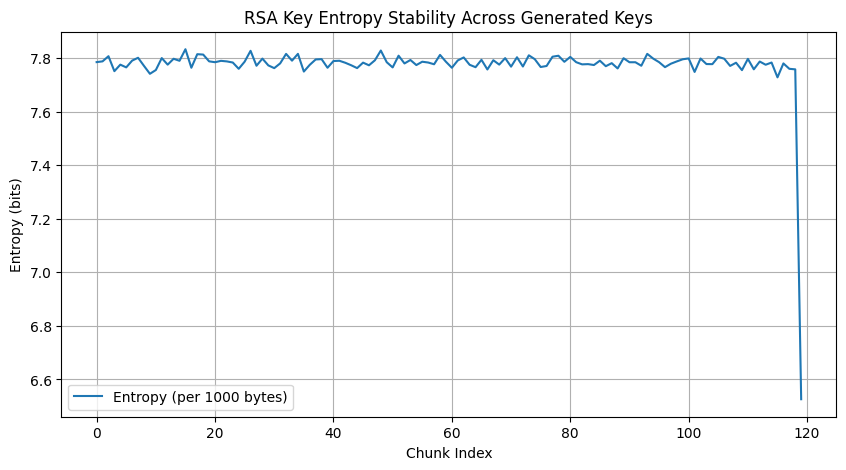

In [ ]:
# ====================================================
# 5️⃣ Visualization
# ====================================================
chunk_size = 1000  # RSA anahtarları büyük, 1000 byte’lık bloklarla analiz
chunk_entropies = []

for i in range(0, len(all_bytes), chunk_size):
    chunk = all_bytes[i:i+chunk_size]
    if len(chunk) > 0:
        chunk_entropies.append(calculate_entropy(chunk))

plt.figure(figsize=(10,5))
plt.plot(chunk_entropies, label="Entropy (per 1000 bytes)")
plt.title("RSA Key Entropy Stability Across Generated Keys")
plt.xlabel("Chunk Index")
plt.ylabel("Entropy (bits)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ====================================================
# 6️⃣ Result Summary (for Academic Reporting)
# ====================================================
summary = {
    "Algorithm": "RSA",
    "Key Length (bits)": key_length,
    "Number of Keys": num_keys,
    "Mean Entropy": round(entropy, 4),
    "Std Entropy": round(np.std(chunk_entropies), 4),
    "Mean Time (ms)": round(mean_time, 4)
}

results_df = pd.DataFrame([summary])
print("\n📊 Summary Table")
display(results_df)


📊 Summary Table


,Algorithm,Key Length (bits),Number of Keys,Mean Entropy,Std Entropy,Mean Time (ms)
0,RSA,2048,100,7.9758,0.1157,605.7269


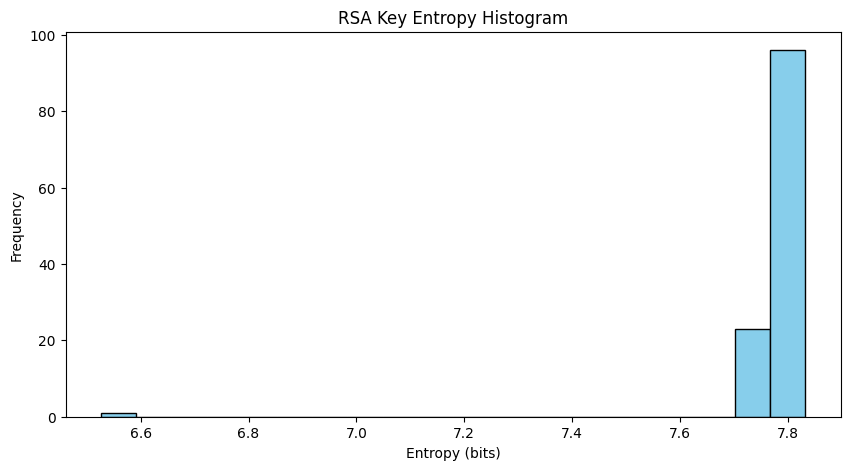

In [ ]:
# 🔹 RSA Key Entropy Histogram
plt.figure(figsize=(10,5))
plt.hist(chunk_entropies, bins=20, color='skyblue', edgecolor='black')
plt.title("RSA Key Entropy Histogram")
plt.xlabel("Entropy (bits)")
plt.ylabel("Frequency")
plt.show()